<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Laberinto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### <span style="color:green;">**LABERINTO**</span>

**Objetivo:**

Analizar el comportamiento de las ratas para que lleguen a su objetivo de llegar a su alimento, utilizando metodos diferentes y concluir con la  probabilidad utilizando metodos diferentes.

**Ejercicio**
En ausencia de aprendizaje, una rata en un laberinto se mueve aleatoriamente. Si hay $k$ formas de abandonar un laberinto, elije una salida con probabilidad $1/k$. ¿Cuál es la probabilidad de que el ratón, iniciando  en la casilla 0, alcance la comida?

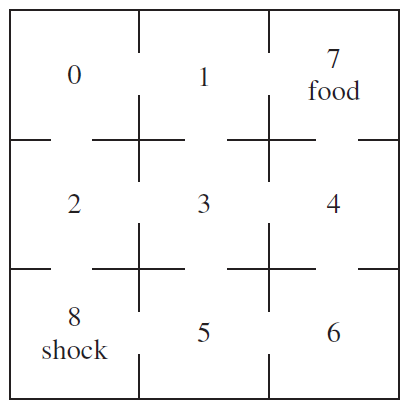




Definimos los estados:



*   Estado 0: punto de incio
*   Estado 1: punto de unión de $A(PA)$
*   Estado 2: punto de inicio
*   Estado 3:
*   Estado 4:



**ANALITICAMENTE SE TIENE:**

Si el tiempo $n$ un raton esta en un cuarto con $k$ habitaciones (adyacentes), elije una de ellas con probabilidad $\frac{1}{k}$

¿Cuál es la probabilidad de que el ratón, iniciando  en la casilla 0, alcance la comida?


**DIAGRAMA DE TRANSICION**

In [22]:
#librerias
import matplotlib.pyplot as plt
import networkx as nx
import sympy as sp

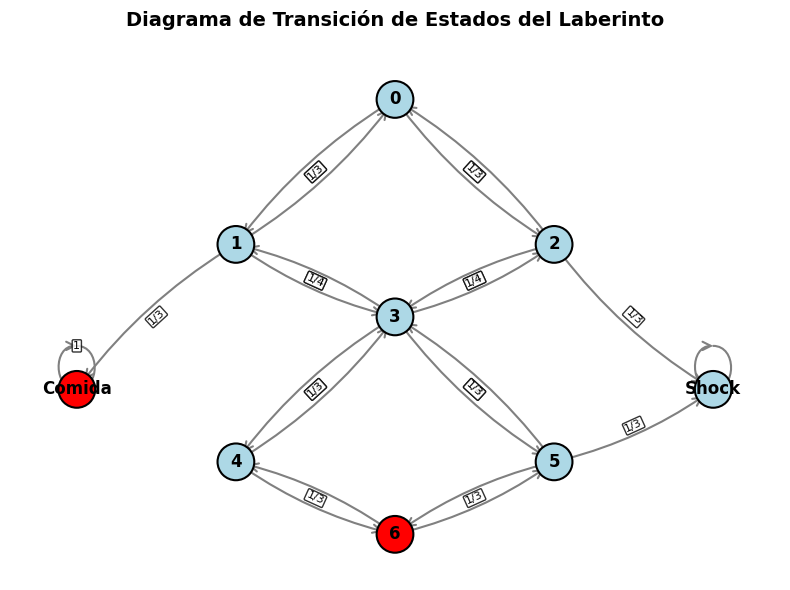

In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import sympy as sp

# Define la matriz de transición 'matriz' con SymPy Rational para fracciones
matriz = sp.Matrix([
        [0, sp.Rational(1,2), sp.Rational(1,2), 0, 0, 0, 0, 0, 0],
    [sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, 0, 0, sp.Rational(1,3), 0],
    [sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, 0, 0, 0, sp.Rational(1,3)],
    [0, sp.Rational(1,4), sp.Rational(1,4), 0, sp.Rational(1,4), sp.Rational(1,4), 0, 0, 0],
    [0, 0, 0, sp.Rational(1,3), 0, 0, sp.Rational(1,3), sp.Rational(1,3), 0],
    [0, 0, 0, sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, sp.Rational(1,3)],
    [0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, sp.Rational(1,2), 0, 0, sp.Rational(1,2), 0, 0, 0]
])

# Configurar la visualización
plt.figure(figsize=(8, 6))

# Crear el grafo (Dirigido, ya que las transiciones tienen dirección)
G = nx.DiGraph() # Inicializa el objeto grafo

# Definir los nodos del laberinto (del 0 al 8)
# Los estados 7 (Comida) y 8 (Electroshock) son absorbentes
nodes = list(range(9))
G.add_nodes_from(nodes)

# Añadir aristas con las probabilidades de transición
# (u, v, probabilidad)
# Estado 0 (inicio)
G.add_edge(0, 1, label=matriz[0,1])
G.add_edge(0, 2, label=matriz[0,2])

# Estado 1 (Junction A)
G.add_edge(1, 0, label=matriz[1,0])
G.add_edge(1, 3, label=matriz[1,3])
G.add_edge(1, 7, label=matriz[1,7]) # A comida

# Estado 2 (Junction B)
G.add_edge(2, 0, label=matriz[2,0])
G.add_edge(2, 3, label=matriz[2,3])
G.add_edge(2, 8, label=matriz[2,8]) # A electroshock

# Estado 3 (Junction C)
G.add_edge(3, 1, label=matriz[3,1])
G.add_edge(3, 2, label=matriz[3,2])
G.add_edge(3, 4, label=matriz[3,4])
G.add_edge(3, 5, label=matriz[3,5])

# Estado 4 (Junction D)
G.add_edge(4, 3, label=matriz[4,3])
G.add_edge(4, 6, label=matriz[4,6])

# Estado 5 (Junction E)
G.add_edge(5, 3, label=matriz[5,3])
G.add_edge(5, 6, label=matriz[5,6])
G.add_edge(5, 8, label=matriz[5,8]) # A electroshock

# Estado 6 (Junction F)
G.add_edge(6, 4, label=matriz[6,4])
G.add_edge(6, 5, label=matriz[6,5])

# Estados absorbentes (ya definidos en la matriz, pero se pueden añadir para claridad visual)
G.add_edge(7, 7, label=matriz[7,7]) # Comida se mantiene en comida
G.add_edge(8, 8, label=matriz[8,8]) # Electroshock se mantiene en electroshock

# Posición de los nodos para una visualización clara (ajusta según la imagen del laberinto)
pos = {
    0: (0, 3), # Inicio
    1: (-1, 2), # PA
    2: (1, 2), # PB
    3: (0, 1.5), # PC
    4: (-1, 0.5), # PD
    5: (1, 0.5), # PE
    6: (0, 0), # PF
    7: (-2, 1), # Comida
    8: (2, 1)  # Electroshock
}

# Dibujar nodos
# Colorear estados 6 y 7 (absorbentes) de rojo, y el resto (transitorios) de azul claro
nx.draw_networkx_nodes(G, pos,
                      node_color=['red' if n in [6, 7] else 'lightblue' for n in G.nodes()],
                      node_size=700,
                      edgecolors='black',
                      linewidths=1.5)

# Dibujar aristas con flechas simples ->
nx.draw_networkx_edges(G, pos,
                      arrows=True,
                      arrowstyle='->',
                      arrowsize=15,
                      width=1.5,
                      edge_color='gray',
                      connectionstyle='arc3,rad=0.1')

# Etiquetas de los nodos
nx.draw_networkx_labels(G, pos,
                       labels={n: str(n) if n not in [7,8] else ('Comida' if n==7 else 'Shock') for n in G.nodes()},
                       font_size=12,
                       font_weight='bold')

# Etiquetas de las aristas (probabilidades)
edge_labels = {(u, v): f'{d["label"]}' for u, v, d in G.edges(data=True) if d['label'] > 0}
nx.draw_networkx_edge_labels(G, pos,
                            edge_labels=edge_labels,
                            font_size=8,
                            bbox=dict(boxstyle='round,pad=0.1',
                                     facecolor='white',
                                     alpha=0.8))

plt.title('Diagrama de Transición de Estados del Laberinto', fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

---
**Clasificación de Estados**

*   **Estados Absorbentes:** Son aquellos estados en los que, una vez que se entra, no se puede salir (P(i,i)=1). En este laberinto, según la matriz de transición proporcionada, los estados absorbentes son:
    *   **Estado 6**
    *   **Estado 7: Comida (Food)**

*   **Estados Transitorios:** Son los estados desde los que se puede pasar a otros estados (incluyendo estados absorbentes) y de los que es posible salir. En este laberinto, los estados transitorios son:
    *   **Estados 0, 1, 2, 3, 4, 5, 8**

**La matrizde Transicion**

In [49]:
#librerias
import numpy as np
from sympy import Matrix , init_printing
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt

In [25]:
matriz = sp.Matrix([
        [0, sp.Rational(1,2), sp.Rational(1,2), 0, 0, 0, 0, 0, 0],
    [sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, 0, 0, sp.Rational(1,3), 0],
    [sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, 0, 0, 0, sp.Rational(1,3)],
    [0, sp.Rational(1,4), sp.Rational(1,4), 0, sp.Rational(1,4), sp.Rational(1,4), 0, 0, 0],
    [0, 0, 0, sp.Rational(1,3), 0, 0, sp.Rational(1,3), sp.Rational(1,3), 0],
    [0, 0, 0, sp.Rational(1,3), 0, 0, sp.Rational(1,3), 0, sp.Rational(1,3)],
    [0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, sp.Rational(1,2), 0, 0, sp.Rational(1,2), 0, 0, 0]
])

print("Matriz de Transición de P:")

Matriz de Transición de P:


In [26]:
matriz

Matrix([
[  0, 1/2, 1/2,   0,   0,   0,   0,   0,   0],
[1/3,   0,   0, 1/3,   0,   0,   0, 1/3,   0],
[1/3,   0,   0, 1/3,   0,   0,   0,   0, 1/3],
[  0, 1/4, 1/4,   0, 1/4, 1/4,   0,   0,   0],
[  0,   0,   0, 1/3,   0,   0, 1/3, 1/3,   0],
[  0,   0,   0, 1/3,   0,   0, 1/3,   0, 1/3],
[  0,   0,   0,   0,   0,   0,   1,   0,   0],
[  0,   0,   0,   0,   0,   0,   0,   1,   0],
[  0,   0, 1/2,   0,   0, 1/2,   0,   0,   0]])

**Ordenamos la matriz para forma estándar absorbente**

Reordenamos: $T = [0,1,2,3,4,5,8]$, luego $ F = [6,7] $.

La matriz $ P $ tiene bloques:

$$
P = \begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$$

Donde:

* $ Q $ : de transitorios a transitorios (7×7)  
* $ R$ : de transitorios a absorbentes (7×2)  
*  $I$ : identidad 2×2 para 6 y 7.

Construyamos $Q$ y $R$.


In [50]:
transient_states = [0, 1, 2, 3, 4, 5, 8]
absorbing_states = [6, 7]

# Extraer Q (de transitorios a transitorios)
Q_rows = [matriz.row(i) for i in transient_states]
Q_matrix = sp.Matrix([list(row[j] for j in transient_states) for row in Q_rows])

# Extraer R (de transitorios a absorbentes)
R_rows = [matriz.row(i) for i in transient_states]
R_matrix = sp.Matrix([list(row[j] for j in absorbing_states) for row in R_rows])

# Extraer 0 (de absorbentes a transitorios)
Zero_rows = [matriz.row(i) for i in absorbing_states]
Zero_matrix = sp.Matrix([list(row[j] for j in transient_states) for row in Zero_rows])

# Extraer I (de absorbentes a absorbentes)
I_rows = [matriz.row(i) for i in absorbing_states]
I_matrix = sp.Matrix([list(row[j] for j in absorbing_states) for row in I_rows])



In [51]:
print("Matriz Q:")
display(Q_matrix)


Matriz Q:


Matrix([
[  0, 1/2, 1/2,   0,   0,   0,   0],
[1/3,   0,   0, 1/3,   0,   0,   0],
[1/3,   0,   0, 1/3,   0,   0, 1/3],
[  0, 1/4, 1/4,   0, 1/4, 1/4,   0],
[  0,   0,   0, 1/3,   0,   0,   0],
[  0,   0,   0, 1/3,   0,   0, 1/3],
[  0,   0, 1/2,   0,   0, 1/2,   0]])

In [52]:
print("\nMatriz R:")
display(R_matrix)



Matriz R:


Matrix([
[  0,   0],
[  0, 1/3],
[  0,   0],
[  0,   0],
[1/3, 1/3],
[1/3,   0],
[  0,   0]])

In [53]:
print("\nMatriz Cero (Absorbente a Transitorio):")
display(Zero_matrix)



Matriz Cero (Absorbente a Transitorio):


Matrix([
[0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0]])

In [54]:
print("\nMatriz I (Absorbente a Absorbente):")
display(I_matrix)


Matriz I (Absorbente a Absorbente):


Matrix([
[1, 0],
[0, 1]])

**Matriz fundamental**
 $$N = (I - Q)^{-1}$$ y probabilidades $$ B = N \cdot R $$

$B_{i,a}$ = probabilidad empezando en estado transitorio i de terminar en absorbente a.



In [55]:
print('--- Cálculo de la Matriz Fundamental N y Probabilidades B ---\n')

# La matriz I en la fórmula N = (I - Q)^-1 es una matriz identidad del mismo tamaño que Q.
# Como Q es de 7x7 (número de estados transitorios), I_fundamental también será 7x7.
I_fundamental = sp.eye(Q_matrix.shape[0])

# Calcular (I - Q)
IQ_diff = I_fundamental - Q_matrix

# Calcular la inversa de (I - Q) para obtener la Matriz Fundamental N
N_matrix = IQ_diff.inv()

print("Matriz Fundamental N = (I - Q)^-1:")
display(N_matrix)



--- Cálculo de la Matriz Fundamental N y Probabilidades B ---

Matriz Fundamental N = (I - Q)^-1:


Matrix([
[21/10,  57/40,  15/8, 3/2,   3/8,  33/40,  9/10],
[19/20, 143/80, 17/16, 5/4,  5/16,  47/80, 11/20],
[  5/4,  17/16, 43/16, 7/4,  7/16,  17/16,   5/4],
[  3/4,  15/16, 21/16, 9/4,  9/16,  15/16,   3/4],
[  1/4,   5/16,  7/16, 3/4, 19/16,   5/16,   1/4],
[11/20,  47/80, 17/16, 5/4,  5/16, 143/80, 19/20],
[ 9/10,  33/40,  15/8, 3/2,   3/8,  57/40, 21/10]])

In [56]:

# Calcular las probabilidades de absorción B = N * R
B_matrix = N_matrix * R_matrix

print("\nMatriz de Probabilidades de Absorción B = N * R:")
display(B_matrix)


Matriz de Probabilidades de Absorción B = N * R:


Matrix([
[ 2/5,  3/5],
[3/10, 7/10],
[ 1/2,  1/2],
[ 1/2,  1/2],
[ 1/2,  1/2],
[7/10, 3/10],
[ 3/5,  2/5]])

In [57]:

print("Probabilidad desde 0 hasta comida (absorbente 6):", B[0,0])

Probabilidad desde 0 hasta comida (absorbente 6): 2/5


Ahora bien, por *Simulacion* se tiene:

In [58]:


def simulate_mouse(estado_inicial=0, max_pasos=800):
    """Simula el movimiento de un ratón en el laberinto hasta que es absorbido
    por el estado 'Comida' (6) o 'Shock' (7), o alcanza el número máximo de pasos.

    Args:
        estado_inicial (int): El estado inicial del ratón (por defecto, 0).
        max_pasos (int): El número máximo de pasos antes de detener la simulación (por defecto, 800).

    Returns:
        int: 1 si el ratón llega a 'Comida' (estado 6), 0 si llega a 'Shock' (estado 7)
             o si no es absorbido en max_pasos.
    """
    estado = estado_inicial
    # Matriz de transición del laberinto
    P = np.array([
        [0, 1/2, 1/2, 0, 0, 0, 0, 0, 0], # Desde el estado 0
        [1/3, 0, 0, 1/3, 0, 0, 0, 1/3, 0], # Desde el estado 1 (1/3 a estado 7 'Shock')
        [1/3, 0, 0, 1/3, 0, 0, 0, 0, 1/3], # Desde el estado 2 (1/3 a estado 8 'Shock')
        [0, 1/4, 1/4, 0, 1/4, 1/4, 0, 0, 0], # Desde el estado 3
        [0, 0, 0, 1/3, 0, 0, 1/3, 1/3, 0], # Desde el estado 4 (1/3 a estado 6 'Comida', 1/3 a estado 7 'Shock')
        [0, 0, 0, 1/3, 0, 0, 1/3, 0, 1/3], # Desde el estado 5 (1/3 a estado 6 'Comida', 1/3 a estado 8 'Shock')
        [0, 0, 0, 0, 0, 0, 1, 0, 0], # Estado 6 (Comida - absorbente)
        [0, 0, 0, 0, 0, 0, 0, 1, 0], # Estado 7 (Shock - absorbente)
        [0, 0, 1/2, 0, 0, 1/2, 0, 0, 0] # Desde el estado 8
    ])

    for _ in range(max_pasos):
        if estado == 6: return 1  # Llegó a 'Comida'
        if estado == 7: return 0  # Llegó a 'Shock'
        probs = P[estado]
        estado = np.random.choice(len(probs), p=probs)
    return 0 # Si no absorbe en max_pasos

In [41]:
# Realizar simulaciones
num_sims = 800
resultados_sim = [simulate_mouse(estado_inicial=0, max_pasos=800) for _ in range(num_sims)]
prob_est_sim = np.mean(resultados_sim)

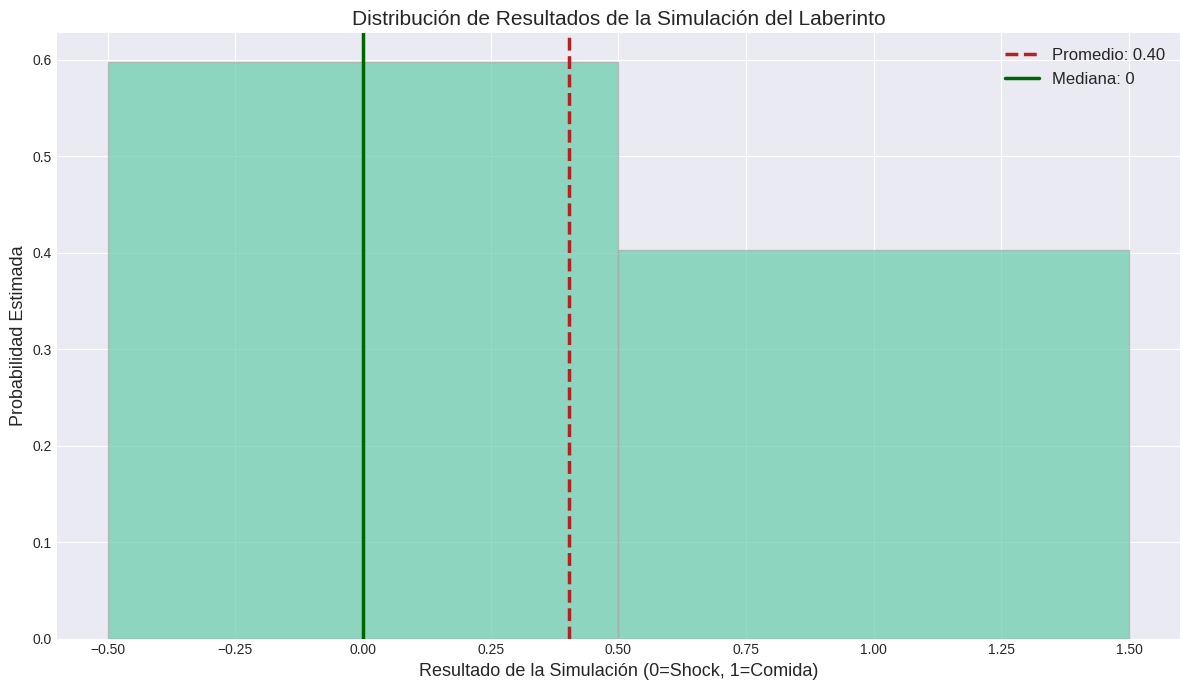

In [47]:


# --- Histograma ---
plt.style.use('seaborn-v0_8-darkgrid') # Cambia el estilo general del gráfico
plt.figure(figsize=(12, 7)) # Aumentar el tamaño de la figura

# Calculate promedio and mediana here as they are used in axvline
promedio = np.mean(resultados_sim)
mediana = np.median(resultados_sim)

plt.hist(resultados_sim,
         bins=np.arange(min(resultados_sim), max(resultados_sim) + 2) - 0.5, # Ajuste de bins para centrar
         edgecolor='darkgray', # Nuevo color de borde
         color='mediumaquamarine', # Nuevo color de las barras
         alpha=0.7, # Ajuste de transparencia
         density=True) # Mantener normalizado

# Línea del promedio
plt.axvline(promedio, color='firebrick', linestyle='--', # Nuevo color para promedio
            linewidth=2.5, label=f'Promedio: {promedio:.2f}')

# Línea de la mediana
plt.axvline(mediana, color='darkgreen', linestyle='-', # Nuevo color para mediana
            linewidth=2.5, label=f'Mediana: {mediana:.0f}')

plt.ylabel('Probabilidad Estimada', fontsize=13) # Etiqueta y tamaño de fuente
plt.xlabel('Resultado de la Simulación (0=Shock, 1=Comida)', fontsize=13)
plt.title('Distribución de Resultados de la Simulación del Laberinto', fontsize=15) # Título y tamaño de fuente
plt.legend(fontsize=12)
# plt.grid(axis='y', alpha=0.3) # Ya incluido en el estilo 'seaborn-v0_8-darkgrid'
plt.tight_layout()
plt.show()

In [43]:
# Intervalo de confianza 95%
std_err = np.std(resultados_sim) / np.sqrt(num_sims)
ci_lower = prob_est_sim - 1.96 * std_err
ci_upper = prob_est_sim + 1.96 * std_err

Probabilidad estimada (simulación): 0.4025
Intervalo de confianza 95%: [0.3685, 0.4365]
Valor analítico: 0.4


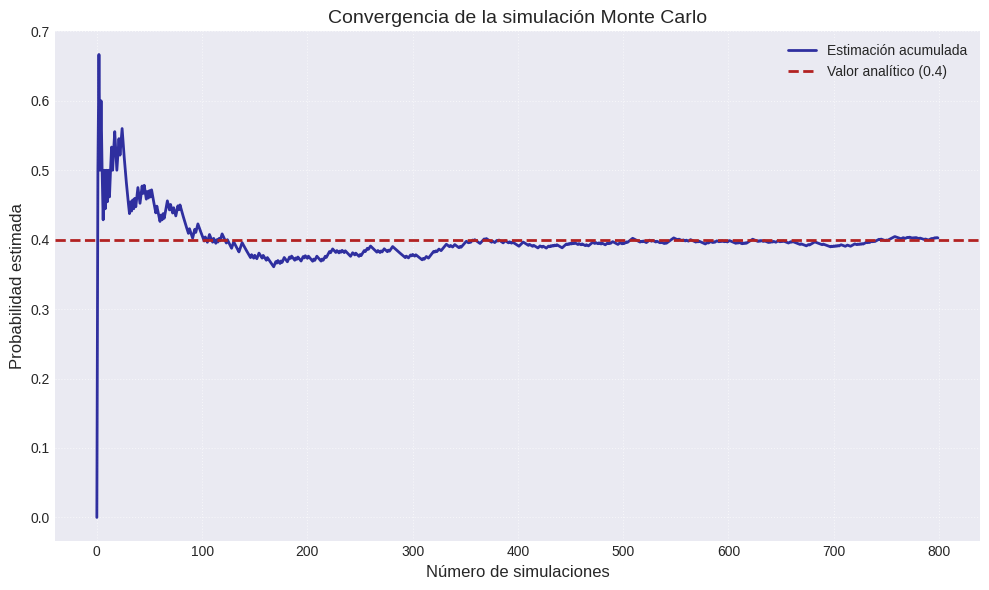

In [46]:
print(f"Probabilidad estimada (simulación): {prob_est_sim:.4f}")
print(f"Intervalo de confianza 95%: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Valor analítico: 0.4")

# Gráfico de convergencia
cumulative_means = np.cumsum(resultados_sim) / (np.arange(num_sims) + 1)

plt.style.use('seaborn-v0_8-darkgrid') # Usa un estilo de gráfico diferente
plt.figure(figsize=(10, 6))

plt.plot(cumulative_means, label='Estimación acumulada', color='darkblue', linestyle='-', linewidth=2, alpha=0.8)
plt.axhline(y=0.4, color='firebrick', linestyle='--', label='Valor analítico (0.4)', linewidth=2)

plt.xlabel('Número de simulaciones', fontsize=12)
plt.ylabel('Probabilidad estimada', fontsize=12)
plt.title('Convergencia de la simulación Monte Carlo', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6) # Cambia el estilo de la cuadrícula
plt.tight_layout() # Ajusta el diseño para evitar recortes
plt.show()

**Verificacion**

Usemos las ecuaciones de Balance para corroborar nuestros analisis anteriores.

Procedamos a utilizar las ecuaciones de balance  $π=(p_0)$ hasta $p_8$

In [37]:
# Definimos variables para p[0..8]
p0, p1, p2, p3, p4, p5, p6, p7, p8 = sp.symbols('p0 p1 p2 p3 p4 p5 p6 p7 p8')

# Ecuaciones (probabilidad de alcanzar 'Comida' (estado 6) antes que 'Shock' (estado 7))
eq0 = sp.Eq(p0, (p1 + p2) / 2)
eq1 = sp.Eq(p1, (p0 + p3) / 3) # p7=0 (shock) en las transiciones desde estado 1
eq2 = sp.Eq(p2, (p0 + p3 + p8) / 3)
eq3 = sp.Eq(p3, (p1 + p2 + p4 + p5) / 4)
eq4 = sp.Eq(p4, (p3 + 1) / 3) # p6=1 (food), p7=0 (shock) en las transiciones desde estado 4
eq5 = sp.Eq(p5, (p8 + p3 + 1) / 3) # p6=1 (food) en las transiciones desde estado 5
eq6 = sp.Eq(p6, 1) # Si está en Comida (estado 6), la probabilidad de alcanzar comida es 1
eq7 = sp.Eq(p7, 0) # Si está en Shock (estado 7), la probabilidad de alcanzar comida es 0
eq8 = sp.Eq(p8, (p2 + p5) / 2)

# Resolver
sol = sp.solve([eq0, eq1, eq2, eq3, eq4, eq5, eq6, eq7,  eq8],
               [p0, p1, p2, p3, p4, p5,p6, p7,  p8])

print("Solución:")
for var, val in sol.items():
    print(f"{var} = {val}")

# Si queremos la respuesta desde el nodo inicial (0):
print("\nProbabilidad desde nodo 0 (inicio):", sol[p0])

Solución:
p0 = 2/5
p1 = 3/10
p2 = 1/2
p3 = 1/2
p4 = 1/2
p5 = 7/10
p6 = 1
p7 = 0
p8 = 3/5

Probabilidad desde nodo 0 (inicio): 2/5


### <span style="color:teal;">**Conclusión:**</span>

En esta práctica se analizó el problema del ratón en el laberinto utilizando cadenas de Markov absorbentes. Se resolvió el problema mediante tres enfoques: la matriz de absorción, las ecuaciones de balance y la simulación de Monte Carlo.

Con la matriz *B* y las ecuaciones de balance se obtuvo el mismo resultado:


$$p_0=\frac{2}{5}=0.4$$


lo que significa que el ratón tiene un $40\%$ de probabilidad de encontrar la comida comenzando desde el estado 0. De igual manera, la probabilidad de terminar en el estado de *Shock* es:


$$ 1-0.4=0.6 $$


La simulación de Monte Carlo también confirmó este resultado, obteniendo una probabilidad aproximada de $0.4025$, muy cercana al valor teórico.

La coincidencia entre las ecuaciones de balance, el análisis matricial y la simulación demuestra que el modelo fue correctamente planteado y que los resultados obtenidos son consistentes.